In [1]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Keras Version:", tf.keras.__version__)

2025-08-09 10:34:24.253577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754728464.437204     863 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754728464.494049     863 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754728464.911884     863 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754728464.911919     863 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754728464.911921     863 computation_placer.cc:177] computation placer alr

Num GPUs Available: 1
Keras Version: 3.11.0


# Chapter 16 | Natural Language Processing with RNNs and Attention
When **Alan Turing** designed the famous **Touring Test** in 1950, he could chose many things to evaluate the machine's ability to match human intelligence: it could have tested for the ability to recognize things in pictures, to play chess, to compose music, to escape a maze, and so on. Interestingly, he chose a **linguistic task**; more precisely, he designed a **chatbot** capable of fooling interlocutor into thinking it was a human. Of course, this test have a lot of weakness and many aspect of the human intelligence are utterly ignored, but it highlights that **mastering language** is arguably the **Homo sapiens' greatest cognitive ability**.

The ultimale goal of **NLP (Natural Language Processing)** is to **build a machine that can master written and spoken language**. Being this task too broad, in practice researchers focus on more specific tasks, such as **text classification**, **translation**, **summarization**, **question answering** and many more. A common approach to NLP tasks is using Recurrent Neural Networks. 

In this chapter, we will explore:
- **Character RNN** (or **Char-RNN**), which is trained to **predict next character in a sentence**;
- **Stateless RNN**, which **learns random portion of text each iteration**, without any information on the rest of the text;
- **Stateful RNN**, which **preserves the hidden state between training and iterations**, continuing to read where it left off, allowing to learn longer patterns;
- RNN for **Sentyment Analysis**, which **extracts feeling** from sentences;
- **Encoder-Decoder** architecture to perform **NMT (Natural Machine Translation)**, translating English to Spanish;
- **Attention Mechanism**, which learn to **select part of inputs** that rest of model **should focus on** at each time step;
- **Transformers**, which is a very powerful **attention-only architecture**;
- Most powerful Language Models;
- Transformers library by Hugging Face.

## Character-RNN to Generate Shakespearean Text
In a famous 2015 blog post titled ["The Unreasonable Effectiveness of Recurrent Neural Networks"](https://karpathy.github.io/2015/05/21/rnn-effectiveness/), the author Andrej Karpathy showed how to train an RNN to predict the next character in a sentence, also called **Character RNN** (or **Char-RNN**). This RNN can then be used to **generate novel text**, once character at a time.

Let's build a char-RNN step by step:

### Creating the Training Dataset
We will use the Keras's tf.keras.utils.get_file() function to download all of Shakespeare's works, which is loaded from Andrej Karpathy's [Char-RNN Project](https://github.com/karpathy/char-rnn).

In [3]:
shakespeare_url = "https://homl.info/shakespeare" #shortcut URL
filepath = tf.keras.utils.get_file('shakespeare.txt', shakespeare_url)
with open(filepath) as f:
    shakespeare_text = f.read()
print(shakespeare_text[:80])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.


We'll then encode this text using **TextVectorization** (Chapter 13); we'll set split = 'character' to get character-level encoding instead of default word-level encoding and standardize = 'lower' to have all text in lowercase:

In [4]:
text_vec_layer = tf.keras.layers.TextVectorization(split = 'character', standardize = 'lower')
text_vec_layer.adapt([shakespeare_text])
encoded = text_vec_layer([shakespeare_text])[0]

I0000 00:00:1754640320.285777     828 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2230 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 SUPER, pci bus id: 0000:29:00.0, compute capability: 7.5


Each character is now mapped to an integer starting from 2 (value 0 is reserved for **padding tokens**, while 1 is reserved for **unknown characters**); considering we won't need either of these 2 tokens for now, we subtract 2:

In [5]:
encoded -= 2
n_tokens = text_vec_layer.vocabulary_size() - 2
dataset_size = len(encoded)

print('Number of Distinct Chars =', n_tokens)
print('Total Number of Chars =', dataset_size)

Number of Distinct Chars = 39
Total Number of Chars = 1115394


As we did in Chapter 15, we can turn this very long sequence into a **dataset of windows** we'll use to train a **sequence-to-sequence RNN**. 

The targets will be similar to the inputs, but shifted by one time step "into the future" (e.g., one sample in the dataset may be a sequence of character IDs representing "to be or not to b" and the corresponding target a sequence of character IDs representing "o be or not to be").

Let's write a function which converts a long sequence of character IDS into a dataset of input/target window pairs:

In [6]:
def to_dataset(sequence, length, shuffle = False, seed = None, batch_size = 32):
    ds = tf.data.Dataset.from_tensor_slices(sequence)
    ds = ds.window(length + 1, shift = 1, drop_remainder = True)
    ds = ds.flat_map(lambda window_ds:window_ds.batch(length + 1))
    if shuffle:
        ds = ds.shuffle(buffer_size = 100_000, seed = seed)
    ds = ds.batch(batch_size)
    return ds.map(lambda window:(window[:, :-1], window[:, 1:])).prefetch(1)

The above function:
- takes a sequence (i.e., encoded text) as input;
- creates a dataset to contain all the windows of the desired length;
- increases the length by one, since we need the next character for the target;
- shuffles the windows (optionally);
- batches the windows;
- splits windows into input/output pairs;
- activates prefetching.

Here's a summary of the code:

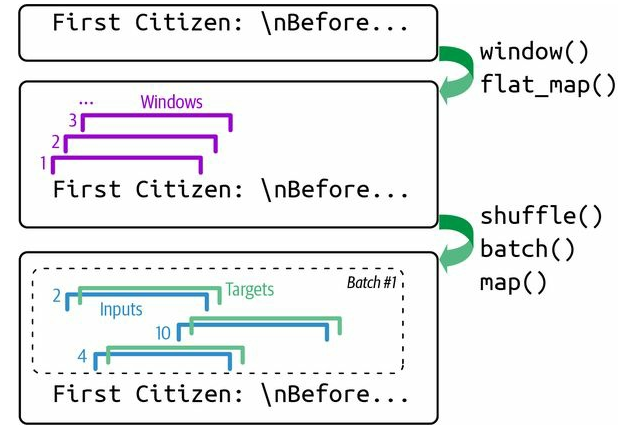

We then create a 90% training set, 5% validation set and 5% testing set:

In [7]:
length = 100
tf.random.set_seed(42)
train_set = to_dataset(encoded[:1_000_000], length = length, shuffle = True, seed = 42)
valid_set = to_dataset(encoded[1_000_000:1_060_000], length = length)
test_set = to_dataset(encoded[1_060_000:], length = length)

NOTE: we set the window length to 100, but we can tune it: shorter window length takes to faster to train RNNs, but also to an RNN which is unable to learn any pattern longer than that length.

### Building and Training the Char-RNN Model
Since our dataset is reasonably large, we need more than a simple RNN with few recurrent nerons; we'll then build and train a model with one GRU layer composed of 128 units:

In [ ]:
import os
model_path = 'my_shakespeare_model.keras'

if os.path.exists(model_path):
    print('Loading model from disk...')
    model = tf.keras.models.load_model(model_path)
    model_ckpt = tf.keras.callbacks.ModelCheckpoint('my_shakespeare_model.keras', monitor = 'val_accuracy', save_best_only = True)
    print('Model Successfully Loaded.')
else:
    print('Training Model...')
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim = n_tokens, output_dim = 16),
        tf.keras.layers.GRU(128, return_sequences = True),
        tf.keras.layers.Dense(n_tokens, activation = 'softmax')
    ])
    model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])
    model_ckpt = tf.keras.callbacks.ModelCheckpoint('my_shakespeare_model.keras', monitor = 'val_accuracy', save_best_only = True)
    history = model.fit(train_set, validation_data = valid_set, epochs = 10, callbacks = [model_ckpt])
    print('Model Successfully Trained.')

Loading model from disk...
Done


Explaining the code above:
- first layer is an Embedding Layer to encode the caracter IDs (embeddings were introduced in Chapter 13); the input dimension is the number of distinct character IDs, while the output dimension is a hyperparameter we can tune, which we set to 16 for now. It takes a 2D tensor of size \[batch size, window length] as input and a 3D tensor of size \[batch size, window length, embedding size] as output;
- second layer is a GRU Layer;
- last layer is a Dense Layer as output layer; it has 39 units (n_tokens) for the 39 distinct characters in the text; at each time step, the probability for each possible character should be computed, so we apply a softmax to the outputs of the Dense Layer.
- we compile the model using the "sparse_categorical_crossentropy" loss and a Nadam optimizer;
- we train the model for several epochs, using a ModelCheckpoint callback to save the best model in terms of valiation accuracy.

This model does not handle text preporcessing, so let's wrap it in a final model containing the TextVectorization as first layer and the Lambda layer to subtract 2 from the character IDs:

In [9]:
shakespeare_model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Lambda(lambda X: X-2),
    model
])

We can finally use it to predict the next character in a sentence:

In [10]:
import numpy as np

y_proba = shakespeare_model.predict(np.array(['To be or not to b'], dtype = 'object'))[0, -1]
y_pred = tf.argmax(y_proba)
text_vec_layer.get_vocabulary()[y_pred + 2]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step


I0000 00:00:1754467700.415003    1071 cuda_dnn.cc:529] Loaded cuDNN version 90300


np.str_('e')

We can also use this model to generate Fake Shakespearean Text: we just feed it some text, make the model predict the most likely next letter, add it to the end of the text, then give the extended text to the model to guess the next letter, and so on; this is known as **Greedy Decoding** (or **Greedy Search**); one problem with this is that it often leads to the same words being repeated over and over again.

Other approaches are **Sampling**, which involves to sample the next character randomly, with a probability equal to the estimated probability; this will generate more diverse and interesting text or **Beam Search**, which involve to extend the sequence with each possible token and keep only the $k$ top sequences (the **Beams**).

We will implement **Sampling** right now, while we'll talk about **Beam Search** later on.

To implement **Sampling**, we have the df.random.categorical() function, which samples random class indices, given the class logits:

In [11]:
log_probas = tf.math.log([0.5, 0.4, 0.1])
tf.random.set_seed(42)
tf.random.categorical([log_probas], num_samples = 8)

<tf.Tensor: shape=(1, 8), dtype=int64, numpy=array([[0, 0, 1, 1, 1, 0, 0, 0]])>

To have more control over the **diversity of the generated text**, we can divide the logits by a number we can tweak as we wish, known as the **temperature**: a temperature close to 0 favors high-probability characters (this is preferred when generating fairly rigid and precise text, such as mathematical equations), while higher temperature gives all character an equal probability (this is preferred when generating more diverse and creative text).

Let's implement the function next_char() to pick the next character to add to the input text using the random sampling + temperature approach:

In [12]:
def next_char(text, temperature = 1):
    y_proba = shakespeare_model.predict([text])[0, -1:]
    rescaled_logits = tf.math.log(y_proba) / temperature
    char_id = tf.random.categorical(rescaled_logits, num_samples = 1)[0, 0]
    return text_vec_layer.get_vocabulary()[char_id + 2] 

And a extend_text() function which takes this char and append it to the given text:

In [13]:
def extend_text(text, n_chars = 50, temperature = 1):
    for _ in range(n_chars):
        text += next_char(text, temperature)
    return text

We can now generate some text:

In [14]:
tf.random.set_seed(42)
print(extend_text(np.array(['To be or not to be'], dtype = 'object'), temperature = 0.01))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

/home/essskevin/tf-env/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_6
Received: inputs=('Tensor(shape=(1,))',)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━

In [33]:
print(extend_text(np.array(['To be or not to be'], dtype = 'object'), temperature = 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━

In [34]:
print(extend_text(np.array(['To be or not to be'], dtype = 'object'), temperature = 100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

As we can see, the text is not that convincing.

A common technique to solve this is to sample only from the top $k$ characters, or from a set of top characters whose total probability exceeds some threshold; this technique is called **Nucleus Sampling**.

Another technique is **Beam Serch**, which we will see soon.

Another approach is to use more GRU layers and more neurons per layer, training for longer and adding some regularization; even changing the window length could be an idea.

Another alternative is to use a **Stateful RNN**.

### Stateful RNN
The ones we used so far are **Stateless RNN**: at each training iteration, the model starts with a hidden state full of 0s, then updates this state at east time step and throws it away at last time step. 

**Stateful RNN**s involve to **preserve this final state** after processing a training batch and use it as the initial state for the next training batch; this allows the model to learn long-term patterns despite only backpropagating through short sequences.

To build a Stateful RNN, we need to use **sequential and nonoverlapping** input sequences (and not shuffled and overlapping sequences we used to train the stateless RNN); this means when creating the tf.data.Dataset we must put shift=length instead of shift=1 and we must not call the shuffle() method.

Batching is much harder when preparing datasets for a stateful RNN: if we call batch(32), then 32 consecutive window would be put in the same batch and the following batch would not continue each of these windows where they left off (first batch would contain windows from 1 to 32, second batch from 33 to 64, so considering the first window of each batch, we would get 1 and 33, which are not consecutive). A simple solution to this is to use a batch size of 1. 

Let's define a custom function which does exactly this:

In [15]:
def to_dataset_for_stateful_rnn(sequence, length):
    ds = tf.data.Dataset.from_tensor_slices(sequence)
    ds = ds.window(length + 1, shift = length, drop_remainder = True)
    ds = ds.flat_map(lambda window: window.batch(length + 1)).batch(1)
    return ds.map(lambda window:(window[:, :-1], window[:, 1:])).prefetch(1)

Here's a summary of this code:

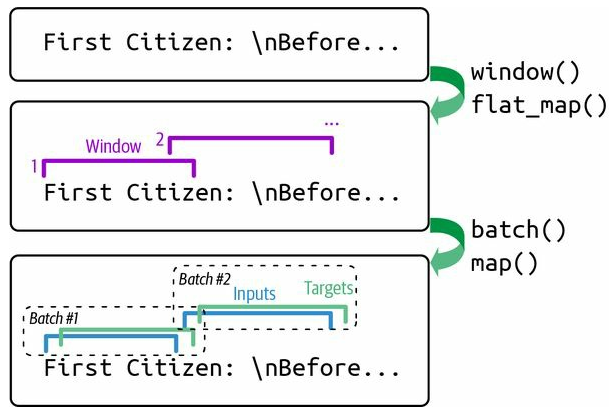

In [16]:
stateful_train_set = to_dataset_for_stateful_rnn(encoded[:1_000_000], length)
stateful_valid_set = to_dataset_for_stateful_rnn(encoded[1_000_000:1_060_000], length)
stateful_test_set = to_dataset_for_stateful_rnn(encoded[1_060_000:], length)

Let's now create the stateful RNN:

(note the stateful=True in the GRU layer)

In [19]:
model = tf.keras.Sequential([
    tf.keras.Input(batch_shape=(1, None), dtype=tf.int32),
    tf.keras.layers.Embedding(input_dim = n_tokens, output_dim = 16),
    tf.keras.layers.GRU(128, return_sequences = True, stateful = True),
    tf.keras.layers.Dense(n_tokens, activation = 'softmax')
])

At end of each epoch, we need to reset the states of each layer before we go back to the beginning of the text, so let's create a custom Keras callback:

In [20]:
class ResetStatesCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs):
        for layer in self.model.layers:
            if hasattr(layer, 'reset_states'):
                layer.reset_states()

Let's now compile the model and train it:

In [29]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])
history = model.fit(stateful_train_set, validation_data = stateful_valid_set, epochs = 10, callbacks = [ResetStatesCallback(), model_ckpt])

Epoch 1/10
   9997/Unknown 270s 27ms/step - accuracy: 0.5459 - loss: 1.4883

2025-08-05 13:49:54.633239: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-08-05 13:49:54.633309: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2025-08-05 13:49:54.633344: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13317217668135356425
2025-08-05 13:49:54.633351: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 15384991311638983546
2025-08-05 13:49:54.633355: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 18401920986454291810
/home/essskevin/tf-env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training.

9999/9999 ━━━━━━━━━━━━━━━━━━━━ 277s 27ms/step - accuracy: 0.5487 - loss: 1.4722 - val_accuracy: 0.5214 - val_loss: 1.6070
Epoch 2/10
   4/9999 ━━━━━━━━━━━━━━━━━━━━ 4:02 24ms/step - accuracy: 0.5827 - loss: 1.3583

2025-08-05 13:50:01.839133: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2025-08-05 13:50:01.839222: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14119687280058454765
2025-08-05 13:50:01.839236: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8294193819374649734
2025-08-05 13:50:01.839239: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14332311010745016012


9997/9999 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5520 - loss: 1.4512

...

2025-08-05 14:26:15.296289: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14119687280058454765
2025-08-05 14:26:15.296330: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8294193819374649734
2025-08-05 14:26:15.296336: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14332311010745016012


9998/9999 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5609 - loss: 1.4123

2025-08-05 14:30:47.582189: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 261867883832694819


9999/9999 ━━━━━━━━━━━━━━━━━━━━ 281s 28ms/step - accuracy: 0.5604 - loss: 1.4163 - val_accuracy: 0.5321 - val_loss: 1.5707


2025-08-05 14:30:56.191919: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 3416633107781300478
2025-08-05 14:30:56.191962: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14119687280058454765
2025-08-05 14:30:56.191981: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8294193819374649734
2025-08-05 14:30:56.191988: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14332311010745016012


Note how this model can only make predictions for batches of the same size of the ones used during training. To avoid this little restriction, we could just create an identical Stateless Model and copy the stateful model's weights to this model.

An interesting thing is that altough these char-RNNs are trained just to perform the simple task of predicting the next character, they are required to learn some higher-level tasks as well. For example, to find the next character after "Great movie, I really", it's helpful to understand the sentence is positive, so what follows is more likely to be "l" (for "loved") rather than "h" (for "hated"). A 2017 [paper](https://arxiv.org/abs/1704.01444) by Alec Radford and other OpenAi researchers describes how the authors trained a big char-RNN on a large dataset and they found out that the neurons acted as an excellent **sentiment analysis classifier**. These neurons were called **sentiment neuron**s and even if they were not trained with any labels, they reached state-of-the-art performances on sentiment analysis benchmarks.

## Sentiment Analysis
It is the most performed kind of **Text Classification**.

If image classification on MNIST dataset is the "Hello world!" of Computer Vision, Sentiment Analysis on the **IMDb reviews dataset** is the "Hello world!" of NLP: this dataset consists of 50_000 movie reviews in English (25_000 for training, 25_000 for testing) extracted from the famous [Internet Movie Database](https://www.imdb.com/it/), with a simple binary target indicating if each review is negative (0) or positive (1).

Let's load the IMBDb dataset using TF Datasets library (we'll use 90% for training and 10% for validation):

In [7]:
import tensorflow_datasets as tfds

raw_train_set, raw_valid_set, raw_test_set = tfds.load(
    name = 'imdb_reviews',
    split = ['train[:90%]', 'train[90%:]', 'test'],
    as_supervised = True
)

tf.random.set_seed(42)
train_set = raw_train_set.shuffle(5000, seed = 42).batch(32).prefetch(1)
valid_set = raw_valid_set.batch(32).prefetch(1)
test_set = raw_test_set.batch(32).prefetch(1)

(NOTE: the tf.keras.datasets.imdb.load_data() already does this and also preprocess the sequences as sequence of word IDs)

Let's look at some reviews:

In [23]:
for review, label in raw_train_set.take(4):
    print(review.numpy().decode('utf-8'))
    print('Label:', label.numpy())

This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
Label: 0
I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot development

2025-08-06 10:12:48.164614: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2025-08-06 10:12:48.177434: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-08-06 10:12:48.178739: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


As we can see, some sentences are easier to cassify (first review contains "terrible movie" and it's a 0), but some are not (third review starts positively, but it's a 0).

We now need to preprocess the text: we will chop the text into words, instead of into characters, again by using tf.keras.layers.TexxtVectorization layer; this layer uses spaces to identify word boundaries, wich is not always optimal depending on language (Chinese does not use spaces, Vietnamese uses spaces within words, German attaches multiple words and even in English sometimes spaces are not the best way to tokenize: think of "San Francisco" or "#ILoveDeepLearning"). Fortunately, there are solutions to these issues.

A 2016 [paper](https://arxiv.org/abs/1508.07909) by Sennrich explored several methods to tokenize and detokenize text at the subword level. One of the techniques the authors evaluated is **Byte Pair Encoding (BPE)**: it splits the whole training set into individual characters (spaces included), then it continuously merges the most frequent adjacent pairs until the vocabulary reaches the desired size.

A 2018 [paper](https://arxiv.org/abs/1804.10959) by Taku Kudo at Google improved subword tokenization, often by removing the need for language-specific preprocessing prior to tokenization; it also introduced a new regularization technique called **Subword Regularization**, which improves accuracy and robustness by introducing some randmness in tokenization during training (e.g., "New England" may be tokenized as "New" + "England", or "New" + "Eng" + "land", or "New England"). The Google's [SentencePiece](https://github.com/google/sentencepiece) is an **open source implementation** of this, with a descriptive [paper](https://arxiv.org/abs/1808.06226) by Taku Kudo and John Richardson.

Going back to our IMDb example, using spaces for token boundaries should be enough, so let's implement it; we will limit vocabulary to 1_000 tokens, including the most frequent 998 words plus a padding token and a token for unknown words (limiting vocabulary size reduces the number of parameters the model needs to learn and avoid model to focus on very rare words).

In [9]:
vocab_size = 1000
text_vec_layer = tf.keras.layers.TextVectorization(max_tokens = vocab_size)
text_vec_layer.adapt(train_set.map(lambda reviews, labels: reviews))

2025-08-06 10:58:05.346220: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


We then create the model:

In [10]:
embed_size = 128
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(vocab_size, embed_size),
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

We have:
- TextVectorization layer we prepared;
- Embedding layer converting word IDs into embeddings (embedding matrix needs to have one row per token in the vocab_size and one column per embedding dimension; this example uses 128 dimensions, but it's a hyperparameter to tune);
- GRU layer;
- Dense layer with single neuron and sigmoid activation function (it's binary classification), which outputs the probability that the review expresses positive sentiment.

Compile and train it on couple of epochs (we could train for longer for better results):

In [21]:
model.compile(loss = 'binary_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])
history = model.fit(train_set, validation_data = valid_set, epochs = 2)

Epoch 1/2


 49/704 ━━━━━━━━━━━━━━━━━━━━ 1:01 95ms/step - accuracy: 0.8409 - loss: 0.3625

KeyboardInterrupt: 

Sadly, this model will generally fail to learn anything, with an accuracy close to 50% (no better than random chance). 

This mainly happens because reviews have different length, taking TextVectorization to pad the shorter sequences using the padding token (ID 0) to make them long as the longest sequence in the batch, meaning a lot of sequences with many padding tokens (even hundreds of them), challenging the GRU layer short-term memory (when it goes through many padding tokens it ends up forgetting what the review was about).

One solution is to feed the model with **equal-length sentences batches**, which also speeds up training; another one is to make the RNN ignore the padding tokens by using **Masking**:

### Masking
It is a technique used to make the RNN **ignore the padding tokens**. It works by creating a **mask tensor** equal to tf.math.not_equal(inputs, 0), which is a Boolean tensor with same shape as input, containing False if token IDs are 0, True otherwise. At each time step, the recurrent layer uses the call() method, and if it has a mask argument, it uses it automatically: if a layer encounters a masked time step, it simply copies the output from the previous time step.

Then, if the layer has supports_masking=True, the mask is propagated to next layers, as long as the layers have supports_masking=True. Putting return_sequences=True automatically puts support_masking=True, while return_sequences=False puts support_masking=False; this means the mask will be propagated till a layer with return_sequences=False is found: this layer will use the mask to ignore the masked steps, but will not propagate the mask anymore.

It can be straightforward to implement, since the Embedding layer accepts the parameter mask_zero=True, which automatically ignores padding tokens (ID 0). Retraining the previous model for few epochs with this takes the validation accuracy from 50% to over 80%:

In [12]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(vocab_size, embed_size, mask_zero=True),
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

In [32]:
model.compile(loss = 'binary_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])
history = model.fit(train_set, validation_data = valid_set, epochs = 2)

Epoch 1/2


704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.7007 - loss: 0.5572 - val_accuracy: 0.8236 - val_loss: 0.4009
Epoch 2/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.8599 - loss: 0.3315 - val_accuracy: 0.8732 - val_loss: 0.3078


Another approach for masking is to set ragged=True in TextVectorizationLayer, which makes the input sequence a ragged tensor:

In [13]:
text_vec_layer_ragged = tf.keras.layers.TextVectorization(max_tokens = vocab_size, ragged = True)

print('Regular Tensor Representation', text_vec_layer(['Great Movie!', 'This is DiCaprio\'s best role.']))
print('Ragged Tensor Representation', text_vec_layer_ragged(['Great Movie!', 'This is DiCaprio\'s best role.']))

Regular Tensor Representation tf.Tensor(
[[ 86  18   0   0   0]
 [ 11   7   1 116 217]], shape=(2, 5), dtype=int64)


2025-08-06 10:58:41.174812: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at lookup_table_op.cc:932 : FAILED_PRECONDITION: Table not initialized.
2025-08-06 10:58:41.174859: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: FAILED_PRECONDITION: Table not initialized.


FailedPreconditionError: Exception encountered when calling TextVectorization.call().

[1m{{function_node __wrapped__LookupTableFindV2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Table not initialized. [Op:LookupTableFindV2] name: [0m

Arguments received by TextVectorization.call():
  • inputs=["'Great Movie!'", '"This is DiCaprio\'s best role."']

(NOTE: at the time of this book, we can't use ragged tensors as targets when running on the GPU, so the first approach may be better)

Now, we'll use tf.keras.callbacks.TensorBoard() callback to visualize the embeddings in TensorBoard as they are being learned.

To do so, the first thing we do is creating a **log directory**, in which Tensorboard will store its event files:

In [40]:
%load_ext tensorboard

In [25]:
import os
import datetime

# Create Unique Log Directory with Timestamp
log_dir = "/home/essskevin/projects/handsonML/16_NLP_with_RNNs_and_Attention/logs"
os.makedirs(log_dir, exist_ok = True)

# Create the TensorBoard callback with thath Directory
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir = log_dir, histogram_freq = 1)

Model it's the same:

In [23]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(vocab_size, embed_size, mask_zero=True),
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

Compile it:

In [28]:
model.compile(loss = 'binary_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])

Call it on sample input (this lets TF initialize the model, avoiding issues reguarding TensorBoard not showing the graph):

In [29]:
sample_input = tf.constant(["sample text here"])
model(sample_input)

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.28240663]], dtype=float32)>

And we add the callback to fit:

In [30]:
history = model.fit(train_set, validation_data = valid_set, epochs = 2, callbacks = [tensorboard_cb])

Epoch 1/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 108ms/step - accuracy: 0.9028 - loss: 0.2442 - val_accuracy: 0.8628 - val_loss: 0.3266
Epoch 2/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 107ms/step - accuracy: 0.9109 - loss: 0.2235 - val_accuracy: 0.8620 - val_loss: 0.3367


### Reusing Pretrained Embeddings and Language Models
Instead of training word embeddings, there's the possibility to download and use **pretrained embeddings** (usually pretrained over very large text data). The idea is that those embeddings would be useful for sentiment analysis even if they were trained on another task (e.g., the words "awesome" and "amazing" will be put in the same cluster in the embedding space even if trained for tasks like predicting the next word in a sentence).

Famous downloadable pretrained embeddings are:
- **Google's** [Word2vec](https://arxiv.org/abs/1310.4546);
- **Stanford's** GloVe;
- **Facebook's** [FastText](https://fasttext.cc/).

This approach was popular for several years, but has its limit: for example, think about the word "right", which is encoded in the same way in "left and right" and "right and wrong", even though it means 2 very different things; to address this, a 2018 [paper](https://arxiv.org/abs/1802.05365) by Matthew Peters introduced **Embeddings from Language Models (ELMo)**, which are **contextualized word embeddings** learned from the internal states of a deep bidirectional language model (instead of just using the pretrained embeddings in our model, we reuse part of a pretrained language model).

Around the same time, the [Universal Language Model Fine-Tuning (ULMFiT) paper](https://arxiv.org/abs/1801.06146) by Jeremy Howard and Sebastian Ruder, demonstrated the effectiveness of unsupervised pretrained for NLP tasks: they trained an LSTM language model on a huge text corpus using **self-supervised learning** (i.e., labels are automatically generated from the data) and they fine-tuned it on various tasks, outperforming the state of the art on 6 text classification tasks by a large margin (error rate reduction of 18-24% in most cases).

Moreover, they showed a pretrained model fine-tuned on just 100 labeled examples, achieving the same performances as one trained from scratch on 10_000 examples. This last paper marked the beginning of a new era in NLP, going from using just pretrained embeddings towards preferring to reuse pretrained language models (this was the norm in computer vision, but not in NLP yet).

Let's build a classifier based on the [Universal Sentence Encoder](https://arxiv.org/abs/1803.11175), a model architecture introduced by a team of Google researcher, based on the **Transformer Architecture** (we will go deeper in this later in the chapter). We can easily find that architecture on Tensorflow Hub:

In [5]:
import os 
import tensorflow_hub as hub

os.environ['TFHUB_CACHE_DIR'] = 'my_tfhub_cache'
model = tf.keras.Sequential([
    hub.KerasLayer('https://tfhub.dev/google/universal-sentence-encoder/4', trainable = True, dtype = tf.string, input_shape = []),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')    
])

model.compile(loss = 'binary_cropssentropy', optimizer = 'nadam', metrics = ['accuracy'])
model.fit(train_set, validation_data = valid_set, epochs = 10)

KeyboardInterrupt: 

(Last part of the TensorFlow Hub URL specifies we want version 4 of the mode, so that things don't break down with new releases)

Note how we set trainable=True, to that the pretrained Universal Sentence Encoder is fine-tuned (not all TensorFlow Hub modules are fine-tunable, so check the documentation).

This model should reach a validation accuracy of over 90% (if we would try to perform the task ourselves, we would probably do marginally better, since some reviews are ambiguous and contain both positive and negative comments).

## Neural Machine Translation (NMT)
These are mainly **Encoder-Decoder** architectures.

We will begin with an NMT model which translates English sentences to Spanish.

The architecture in short is:
- an **Encoder**, in which we fed the English sentences as input;
- a **Decoder**, which outputs the Spanish translations.

One technique that is used is **teacher forcing**, which involves at each step to give as input to the decoder the word that it should have output at the previous step, regardless of what it actually did output (this technique significantly increases training speed and model's performance); for the very first word, the decoder is given the **Start-of-Sequence (SOS) token**, and the decoder is expected to end the sentence with an **End-of-Sentence (EOS) token**.

Each word is initiallty represented by its ID (a number), and then an Embedding layer returns the embedding of each, before fedding them to the encoder and decoder.

At each step, the decoder outputs a score for each word in the output vocabulary and the softmax turns these into probabilities.

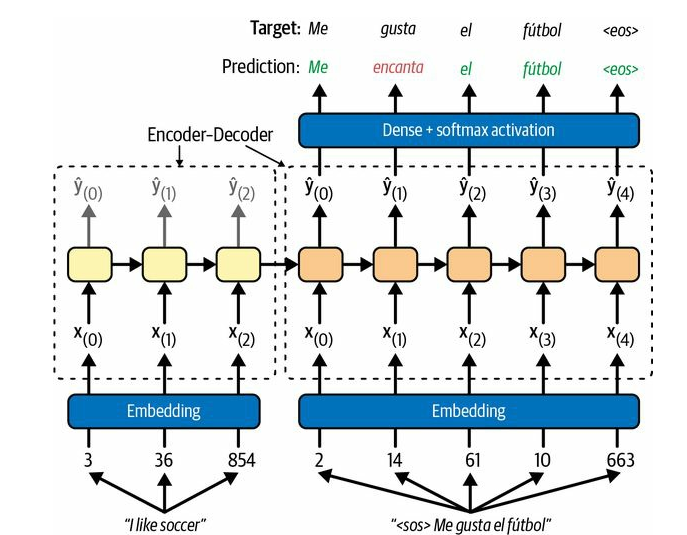

After training, so at inference time, we won't have the target sentence to feed to decoder (we want the model to output this); instead, we will feed the word that it has just output at the previous step:

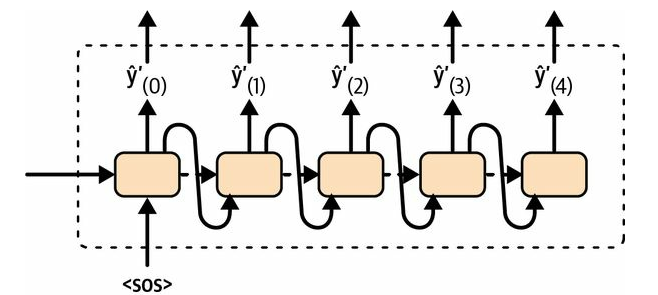

(This needs an embedding lookup, which is not shown in the diagram)

Let's download a dataset of English/Spanish sentence pairs:

In [9]:
from pathlib import Path

url = "https://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"

# Download and extract the zip
zip_path = tf.keras.utils.get_file(
    "spa-eng.zip", origin=url, cache_dir="datasets", extract=True
)

# Construct the correct path based on actual structure
spa_file = Path(zip_path).parent / "spa-eng_extracted" / "spa-eng" / "spa.txt"

# Read the text
text = spa_file.read_text(encoding="utf-8")

print(text[:500])


2638744/2638744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Go.	Ve.
Go.	Vete.
Go.	Vaya.
Go.	Váyase.
Hi.	Hola.
Run!	¡Corre!
Run.	Corred.
Who?	¿Quién?
Fire!	¡Fuego!
Fire!	¡Incendio!
Fire!	¡Disparad!
Help!	¡Ayuda!
Help!	¡Socorro! ¡Auxilio!
Help!	¡Auxilio!
Jump!	¡Salta!
Jump.	Salte.
Stop!	¡Parad!
Stop!	¡Para!
Stop!	¡Pare!
Wait!	¡Espera!
Wait.	Esperen.
Go on.	Continúa.
Go on.	Continúe.
Hello!	Hola.
I ran.	Corrí.
I ran.	Corría.
I try.	Lo intento.
I won!	¡He ganado!
Oh no!	¡Oh, no!
Relax.	Tomátelo con soda.
Smile.	Sonríe.
Attack!	¡Al ataque!
Attack!	¡Atacad!
Ge


We'll start my removing the Spanish characters “¡” and “¿”, which TextVectorization layer can't handle; we will then parse the sentence pairs and shuffle them; then we will split them into 2 separate lists, one per language:

In [10]:
import numpy as np

text = text.replace("¡", "").replace("¿", "")
pairs = [line.split("\t") for line in text.splitlines()]
np.random.shuffle(pairs)
sentences_en, sentences_es = zip(*pairs)

for i in range(3):
    print(sentences_en[i], "=>", sentences_es[i])

Tom dressed himself quickly, then ran out the door. => Tom se vistió rápidamente, luego salió corriendo por la puerta.
Tom knew Mary wasn't happy. => Tom sabía que Mary no era feliz.
This isn't the last train, is it? => Este no es el último tren, verdad?


Now, we create 2 TextVectorization layers, one per language, adpating them to the text:

In [11]:
vocab_size = 1_000
max_length = 50
text_vec_layer_en = tf.keras.layers.TextVectorization(vocab_size, output_sequence_length=max_length)
text_vec_layer_es = tf.keras.layers.TextVectorization(vocab_size, output_sequence_length=max_length)
text_vec_layer_en.adapt(sentences_en)
text_vec_layer_es.adapt([f'startofseq {s} endofseq' for s in sentences_es])

Note how:
- vocab_size=1000, which is quite small: that is done because training set is not very large and using a small vocabulary size will speed up training. State-of-the-art translation models typically use large vocabulary size (e.g., 30000), larger training set (gigabytes), and larger model (hundreds or even thousands of megabytes); examples of these models are Oput-MT model by University of Helsinki, or the M2M-100 model by Facebook;
- output_sequence_length=50, which is the maximum length of the sentences in the dataset (shorter inputs will be automatically padded with 0s until 50 tokens is reached; in case of larger inputs, they would be cropped to 50 tokens);
- we added "startofseq" (the SOS token) and "endofseq" (the EOS token) to each sentence of the Spanish text (any word works, as long as they are not actual Spanish words).

Let's now explore the first 10 tokens in both vocabularies (they appear sorted in decreasing frequency):

In [27]:
text_vec_layer_en.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('i'),
 np.str_('to'),
 np.str_('you'),
 np.str_('tom'),
 np.str_('a'),
 np.str_('is'),
 np.str_('he')]

In [26]:
text_vec_layer_es.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('startofseq'),
 np.str_('endofseq'),
 np.str_('de'),
 np.str_('que'),
 np.str_('a'),
 np.str_('no'),
 np.str_('tom'),
 np.str_('la')]

Let's now create a training set and a validation set; we'll use first 100k sentence pairs for training, while rest for validation. The decoder's inputs are the Spanish sentences plus the SOS token prefix; the targets are the Spanish sentences plus an EOS suffix.

In [12]:
X_train = tf.constant(sentences_en[:100_000])
X_valid = tf.constant(sentences_en[100_000:])
X_train_dec = tf.constant([f'startofseq {s}' for s in sentences_es[:100_000]])
X_valid_dec = tf.constant([f'startofseq {s}' for s in sentences_es[100_000:]])
Y_train = text_vec_layer_es([f'{s} endofseq' for s in sentences_es[:100_000]])
Y_valid = text_vec_layer_es([f'{s} endofseq' for s in sentences_es[100_000:]])

Let's now build the model; we will use the Functional API, since model is not sequential; let's start by the inputs:

In [13]:
encoder_inputs = tf.keras.layers.Input(shape = [], dtype = tf.string)
decoder_inputs = tf.keras.layers.Input(shape = [], dtype = tf.string)

Now, we encode the sentences using the TextVectorization layers we prepared, followed by an Embedding layer for each language, with masking (embedding size is an hyperparameter we can tune):

In [14]:
embed_size = 128

encoder_input_ids = text_vec_layer_en(encoder_inputs)
decoder_input_ids = text_vec_layer_en(decoder_inputs)

encoder_embedding_layer = tf.keras.layers.Embedding(vocab_size, embed_size, mask_zero=True)
decoder_embedding_layer = tf.keras.layers.Embedding(vocab_size, embed_size, mask_zero=True)

encoder_embeddings = encoder_embedding_layer(encoder_input_ids)
decoder_embeddings = decoder_embedding_layer(decoder_input_ids)

(NOTE: if languages share many words, we may get better performances using same embbedding layer for encoder and decoder)

Let's now create the encoder and pass it the embedded inputs:

In [15]:
encoder = tf.keras.layers.LSTM(512, return_state=True)
encoder_outputs, *encoder_state = encoder(encoder_embeddings)

What we did above:
- we stacked a single LSTM layer (more can be used); return_state=True to get a reference to the layer's final state;
- since LSTM layer returns the state splitting it in 2 (short-term and long-term), we wrote *encoder_state to group both states in a list.

We can now use this double state as initial state for decoder:

In [47]:
decoder = tf.keras.layers.LSTM(512, return_sequences = True)
decoder_outputs = decoder(decoder_embeddings, initial_state = encoder_state)

We then pass the decoder's outputs through a Dense layer with softmax activation to get word probabilities for each step:

In [17]:
output_layer = tf.keras.layers.Dense(vocab_size, activation = 'softmax')
Y_proba = output_layer(decoder_outputs)

When output vocabulary is large, computing the softmax function over such a large vector is computationally intensive; the main alternative to this is called [Sampled Softmax](https://arxiv.org/abs/1412.2007), introduced in 2015, which involves to look only at the logits output by the model for the correct word and for a random sample of incorrect words, then compute an approximation of the loss based only on these logits. In TF, just use tf.nn.sampled_softmax_loss() during training and use the normal softmax function at inference time (sampled_softmax can't be performed at inference time cause it needs the target value).

Another thing to speed up training, also compatible with Sampled Softmax, is to **tie the weights** of the output layer to the transpose of the decoder's embedding matrix (Chapter 17); this reduces the number of model parameters, speeding up training and usually boosting performance. The idea is that embedding matrix is equivalent to one.hot encoding followed by linear layer with no bias and no activation that maps the one-hot vectors to the embedding space; the output layer does the reverse, so if model can find an embedding matrix whose transpose is close to its inverse (i.e., the orthogonal matrix), then there's no need to learn a separate set of weights for the output layer.

We can now create the model, compile it and train it:

In [34]:
model = tf.keras.Model(inputs = [encoder_inputs, decoder_inputs],
                       outputs = [Y_proba])
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])
model.fit((X_train, X_train_dec), Y_train, epochs = 10, validation_data = ((X_valid, X_valid_dec), Y_valid))

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 139s 44ms/step - accuracy: 0.0687 - loss: 3.3641 - val_accuracy: 0.0636 - val_loss: 2.6887
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 138s 44ms/step - accuracy: 0.0670 - loss: 2.3697 - val_accuracy: 0.0706 - val_loss: 2.1834
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 139s 44ms/step - accuracy: 0.0745 - loss: 1.9760 - val_accuracy: 0.0743 - val_loss: 1.9876
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 139s 44ms/step - accuracy: 0.0792 - loss: 1.7571 - val_accuracy: 0.0763 - val_loss: 1.9040
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 134s 43ms/step - accuracy: 0.0832 - loss: 1.5961 - val_accuracy: 0.0769 - val_loss: 1.8728
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 138s 44ms/step - accuracy: 0.0870 - loss: 1.4603 - val_accuracy: 0.0771 - val_loss: 1.8770
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 139s 44ms/step - accuracy: 0.0904 - loss: 1.3397 - val_accuracy: 0.0773 - val_loss: 1.8947
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 137s 44ms/step - accuracy: 

Using this model to translate new English sentences to Spanish is not that straightforward as calling mode.predict(), because decoder expects as input the word that was predicted at the previous time step.

Let's write a little utility function that creates a custom memory cell keeping track of the previous output and feeds it to the encoder at next time step:

In [47]:
def translate(sentence_en):
    translation = ''
    for word_idx in range(max_length):
        X = np.array([sentence_en], dtype = 'object') #encoder input
        X_dec = np.array(['startofseq' + translation], dtype = 'object') #decoder input
        y_proba = model.predict((X, X_dec))[0, word_idx] #last token's probas
        predicted_word_id = np.argmax(y_proba)
        predicted_word = text_vec_layer_es.get_vocabulary()[predicted_word_id]
        if predicted_word == 'endofseq':
            break
        translation += ' ' + predicted_word
    return translation.strip()

If we play with this model, we can easily note how it is not bilingual yet, and in particular it struggles with longer sentences.

In [51]:
translate('I like playing soccer')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


'me gusta jugar al fútbol'

In [62]:
translate('I like playing soccer and hanging out with my friends')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


'me gusta jugar a jugar hijos y mis sus mis con sus amigos'

The performance on long sentences could be improved by increasing training size and add more LSTM layers in both encoder and decoder, but this won't take the model so far.

Let's then explore more sophisticated techniques:

### Bidirectional RNNs
In a regular recurrent layer, at each time step it looks at past and present inputs before generating its output, without the possibility to look into the future. This type of RNN makes sense when forecasting time series or in a decoder of a seq2seq model, but nof it tasks like text classification or in a decoder of a seq2seq model, where it would be great to look at the next words before encoding the given word (e.g., the word "right" would have different meaning wheter the next words are either "arm" or "choice" or "to criticize").

This lead us to **Bidirectional RNNs**, in which we have 2 recurrent layers running on the same inputs, one reading the words from left to right and the other from right to left, in order to then combine their outputs at each time step (typically concatenating them).

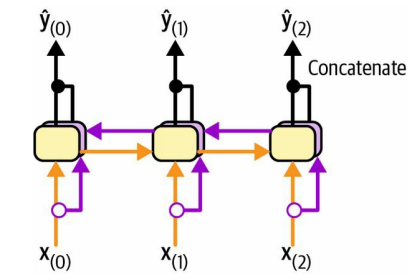

This can be easily done in Keras by wrapping a recurrent layer in a tf.keras.layers.Bidirectional:

In [18]:
encoder = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(256, return_state = True))

This creates a clone of the LSTM layer, but in the reverse direction (if the layer has 256 units, it will output 512 values per time step).

But now, the layer will return 4 states instead of 2 (final short-term and long-term states of both forward and backward LSTM layer), so we can't just feed them in as initial state of the decoder's LSTM layer, which expects just 2 states (final short-term and long-term). A solution for this is just to concatenate the 2 short-term states, obtaining 1 short-term state, and the 2 long-term states, obtaining 1 long-term state:

In [19]:
encoder_outputs, *encoder_state = encoder(encoder_embeddings)
encoder_state = [tf.keras.layers.Concatenate(encoder_state[::2]), #short-term (0 and 2)
                 tf.keras.layers.Concatenate(encoder_state[1::2])] #long-term (1 and 3)

### Beam Serch
It is another popular technique to improve performance of a translation model at inference time.

This technique **keeps track of a short list of $k$ most promising sentences**, trying to extend them at each decoder step (parameter $k$ is called **beam width**).

Let's see an example:

suppose we want to translate the sentence "I like soccer" to Spanish using an RNN without using Beam Serch; the correct translation would be "me gusta el fútbol", but unfortunately it outputs "me gustan los jugadores", which means "I like the players"; by looking at the training set, we notice there are a lot of sentences such as "I like cars", which translates to "me gustan los autos". Apparently, the model is likely to translate "I like" into "me gustan los", so once at the time step where "soccer" should be translated, the model could not go back and fix it, so it completed "me gustano los" with the most likely word, which was "jugadores".

With Beam Search, and supposing a beam width of 3:

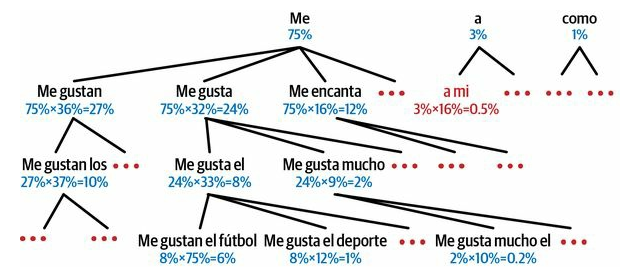

- at first time step the model outputs an estimated probabilities for each possible first word in the sentence; we keep the top $k=3$ which let's suppose are 'me'=75%, 'a'=3%, 'como'=1%;
- at the next time step the model outputs the estimated (conditional) probabilities for each possible second word in the sentence and we still keep the top 3: let's suppose that given the sentence starts with 'me', the top 3 words are 'gustan=36%', 'gusta=32%' and 'encanta'=16% while given it start with 'a' or 'como', the top 3 words are others. Assuming a 1_000 words vocabulary, we will end with 1_000 probabilities per sentence;
- we then compute the probabilities of each of the 3_000 (3 sentence x 1000 probabilities) 2-word sentences we considered by multiplying the estimated (conditional) probabilities of each word by the estimated probability of the sentence it completes (e.g., estimated (conditional) probability of word "gustan" was 36% and it completes the sentence "me", which estimated probability was 75%, so estimated probability of sentence "me gustan" is 75% x 36% = 27%). After computing all these, we keep only the top 3;
- the process repeats until the sequence ends.

Even if with Bidirectional RNNs and Beam Search we can improve our model in translation tasks, it will still be really bad at translating long sentences due to the limited short-term memory of RNNs; the game-changing innovation which addressed this problem are the **Attention Mechanisms**.

## Attention Mechanisms
These mechanisms allowed the decoder **to focus on the appropriate tokens** at each time step (e.g., at the time step where decoder needs to output "fútbol", it will focus its **attention** on the word "soccer"). Looking at the above image illustrating the path to go from the word "soccer" to its translation "fútbol" in a traditional Beam Serch mechanism, it's clear that it is quite long. Attention makes this path shorter, reducing the short-term memory limitation impact.

They **revolutionized NLT (and Deep Learning in general)** allowing a significant improvement in the state of the art, especially for long sentences (e.g., over 30 sentences).

Let's see more in depth how does an Encoder-Decoder model with an Attention Meachanism work:

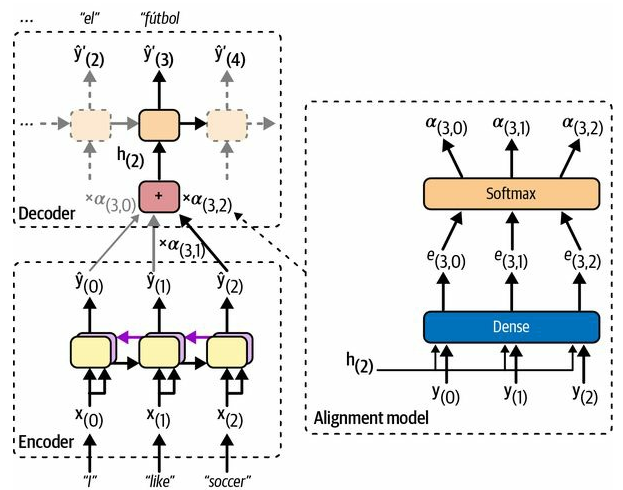

As before, at time step $t$, encoder sends the decoder's final hidden state $h_{(t)}$ and the previous target word to decode (or during inference the last word it predicted), but this time it also sends all of encoder's outputs $y_{(t)}$; these are then processed by a small neural networked call **Alignment Model (or Attention Layer)** which is a single neuron Dense layer computing a weighted sum of the encoder's outputs to produce a **Context Vector**:

$$\overline{h}_{(t)} = \sum_i \alpha_{(t, i)} * y{_(i)}$$

$\alpha_{(t,i)}$ represents the **weight** of word in position $i$ at time step $t$. These weights determine how much attention to pay to word in position $i$ at step $t$ (if weight $\alpha_{(3,2)}$ is much larger than weights $\alpha_{(3,0)}$ and $\alpha_{(3,1)}$, decoder will pay more attention to encoder's output for word #2 ("soccer") than to the other 2 outputs, at this time step). 

More in detail, the Alignment Model processes each of the encoder's outputs $y_{(i)}$ and the decoder's final state $h_{(T)}$ and then outputs a **score (or energy)** $e_{(i, t)}$, which measures **how well each output is aligned with the decoder's hidden state**. 

The way these 2 (encoder outputs and decoder's hidden state) are combined determines different Attention Mechanism variants; one of the most famous, and first introduced, was the **Badhanau Attention (or Concatenative Attention, or Additive Attention)**, which computes the score by concatenating the encoder outputs and decoder's previous hidden state:

$$e_{(t, i)} = v^T tanh(W_{[h_{(t-1)}; y_{(t)}]}) \text{ (Badhanau)}$$

Another common one is the **Luong Attention (or Multiplicative Attention)**, proposed in a 2015 [paper](https://arxiv.org/abs/1508.04025): since the score we are computing is basically a similarity score, the author proposed to compute it as dot product of encoder's output and decoder's hidden state, moreover, it proposed to use the **current hidden state** $h_{(t)}$ instead of the previous hidden state $h_{(t)}$, like Badhanau did:

$$e_{(t, i)} = h_{(t)}^Th_{(i)} \text{ (Luong)}$$

Another approach is the **General Dot Product**, which uses a fully connected layer without bias that takes the encoder outputs to get a **Learned Weight Matrix**:

$$e_{(t, i)} = h_{(t)}^T Wh_{(i)} \text{ (General)}$$

After this, there's a softmax producing the weight $\alpha_{(t,i)}$ out of the scores $$e_{(t, i)}$$ (all weights at each time step sum up to 1). As an example, in the above network we are at time step 3 of translating the sentence "I like soccer", so the model output is already "me gusta el", which means "I like", so it is expecting a noun, taking the word "soccer" to be the one that best aligns with current state, so with high score, so with high weight.

Keras provided tf.keras.layers.Attention, for Luong attention and a tf.keras.layers.AdditiveAttention, for Badhanau.

Let's add a Luong Attention to our encoder-decoder model; since we need the encoder's output, we need to set return_sequences=True in the encoder:

In [48]:
encoder = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(256, return_sequences=True, return_state=True))
encoder_outputs, *encoder_state = encoder(encoder_embeddings)

(Decoder doesn't need changes)

Let's now add the attention_layer: we would need to access the decoder's states at each step, to pass them to the attention layer, but this would require a custom memory cell; for simplicity, we can use the decoder's outputs instead of its states (this works well in practice and it's much easier to code):

In [56]:
mask_decoder = decoder_embeddings._keras_mask
mask_encoder = encoder_embeddings._keras_mask

In [57]:
attention_layer = tf.keras.layers.Attention()
attention_outputs = attention_layer(
    [decoder_outputs, encoder_outputs],
    mask=[mask_decoder, mask_encoder]
)

We then add an output_layer with softmax:

In [58]:
output_layer = tf.keras.layers.Dense(vocab_size, activation='softmax')
Y_proba = output_layer(attention_outputs)

In [59]:
decoder_outputs.shape

(None, 50, 512)

In [52]:
encoder_outputs.shape

(None, 50, 512)

In [54]:
encoder_embeddings._keras_mask

<KerasTensor shape=(None, 50), dtype=bool, sparse=False, ragged=False, name=keras_tensor_5>

<KerasTensor shape=(None, 50), dtype=bool, sparse=False, ragged=False, name=keras_tensor_7>

In [60]:
model = tf.keras.Model(inputs = [encoder_inputs, decoder_inputs],
                       outputs = [Y_proba])
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])
model.fit((X_train, X_train_dec), Y_train, epochs = 10, validation_data = ((X_valid, X_valid_dec), Y_valid))

Epoch 1/10


ValueError: Exception encountered when calling Attention.call().

[1mDimensions must be equal, but are 256 and 512 for '{{node functional_5_1/attention_8_1/MatMul}} = BatchMatMulV2[T=DT_FLOAT, adj_x=false, adj_y=false, grad_x=false, grad_y=false](functional_5_1/lstm_12_1/CudnnRNNV3, functional_5_1/attention_8_1/transpose)' with input shapes: [?,50,256], [?,512,50].[0m

Arguments received by Attention.call():
  • inputs=['tf.Tensor(shape=(None, 50, 256), dtype=float32)', 'tf.Tensor(shape=(None, 50, 512), dtype=float32)']
  • mask=['tf.Tensor(shape=(None, 50), dtype=bool)', 'tf.Tensor(shape=(None, 50), dtype=bool)']
  • training=True
  • return_attention_scores=False
  • use_causal_mask=False